<a href="https://colab.research.google.com/github/NanC-Nabil/NTI/blob/main/Task1%2B3_NTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [4]:
model = Sequential([
    Input(shape=(28, 28)),      # Explicit Input layer for input shape
    Flatten(),                   # Flatten layer without input_shape
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
# Fashion-MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

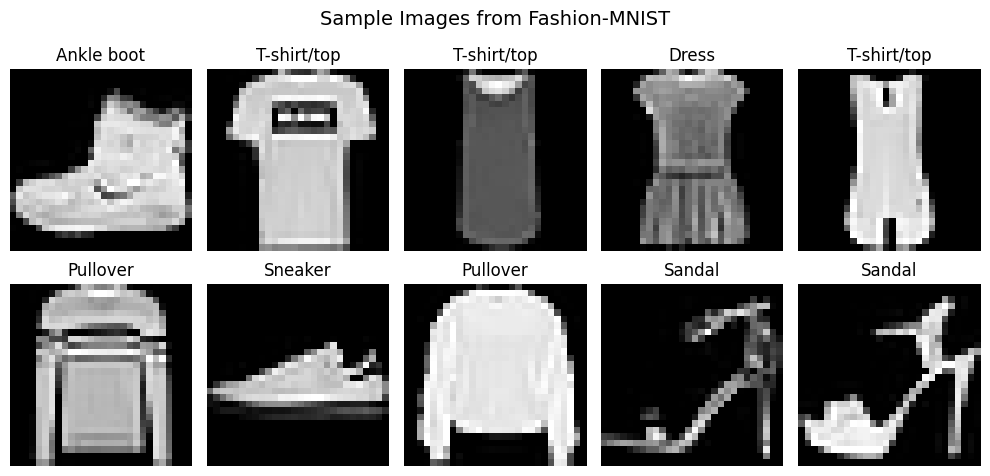

In [6]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle('Sample Images from Fashion-MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8155 - loss: 0.5159 - val_accuracy: 0.8511 - val_loss: 0.4128
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8612 - loss: 0.3816 - val_accuracy: 0.8583 - val_loss: 0.3790
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8739 - loss: 0.3416 - val_accuracy: 0.8637 - val_loss: 0.3717
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8822 - loss: 0.3179 - val_accuracy: 0.8743 - val_loss: 0.3584
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8897 - loss: 0.2957 - val_accuracy: 0.8752 - val_loss: 0.3441
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8944 - loss: 0.2833 - val_accuracy: 0.8718 - val_loss: 0.3566
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8985 - loss: 0.2702 - val_accuracy: 0.8765 - val_loss: 0.3406
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9033 - loss: 0.2578

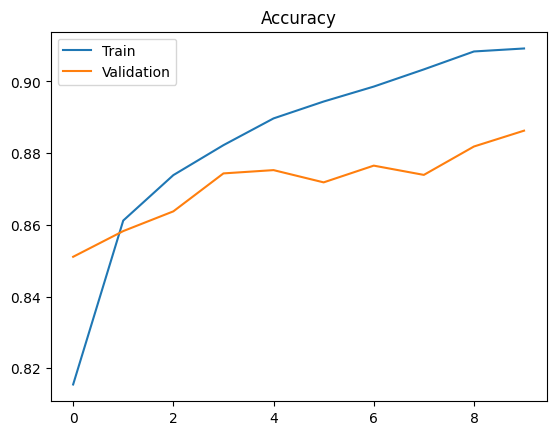

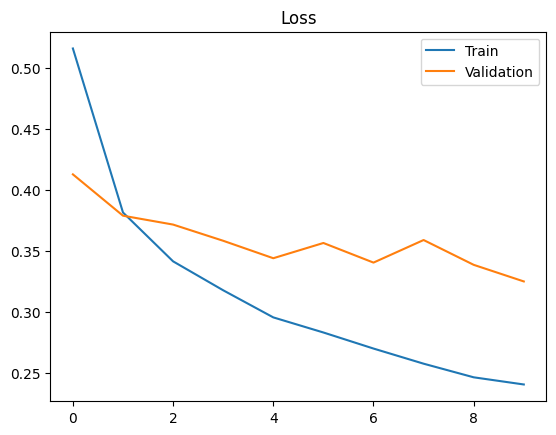

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Test Accuracy: 0.8772

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.82      0.84      1000
     Trouser       0.97      0.98      0.97      1000
    Pullover       0.80      0.73      0.76      1000
       Dress       0.88      0.86      0.87      1000
        Coat       0.69      0.89      0.78      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.76      0.67      0.71      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.96      0.96      0.96      1000
  Ankle boot       0.93      0.98      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



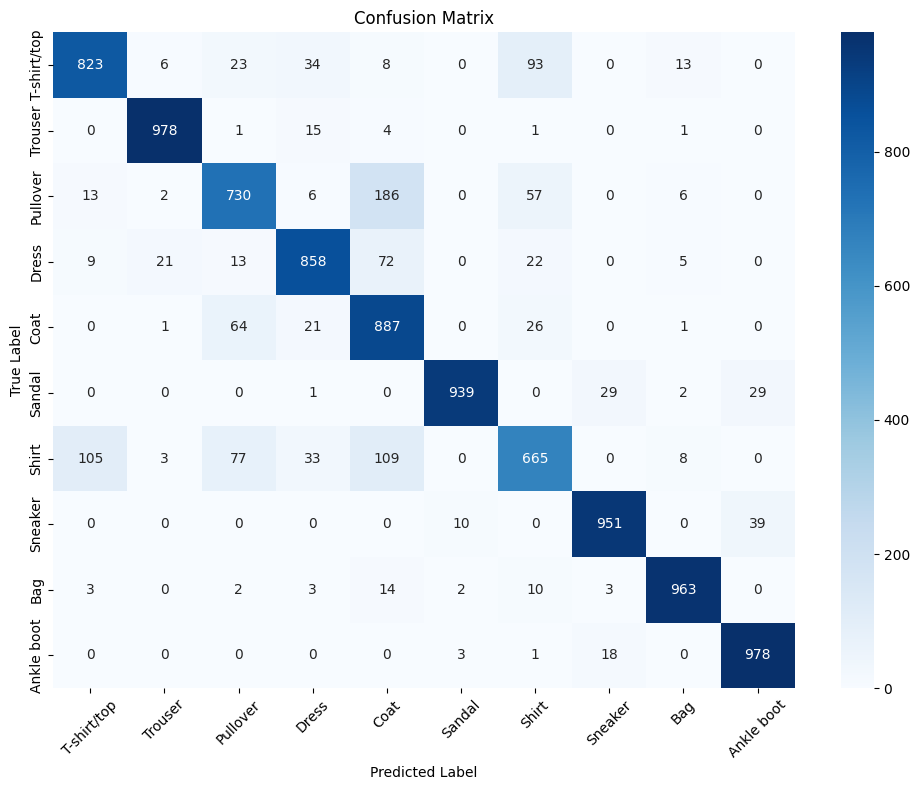

In [9]:
# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


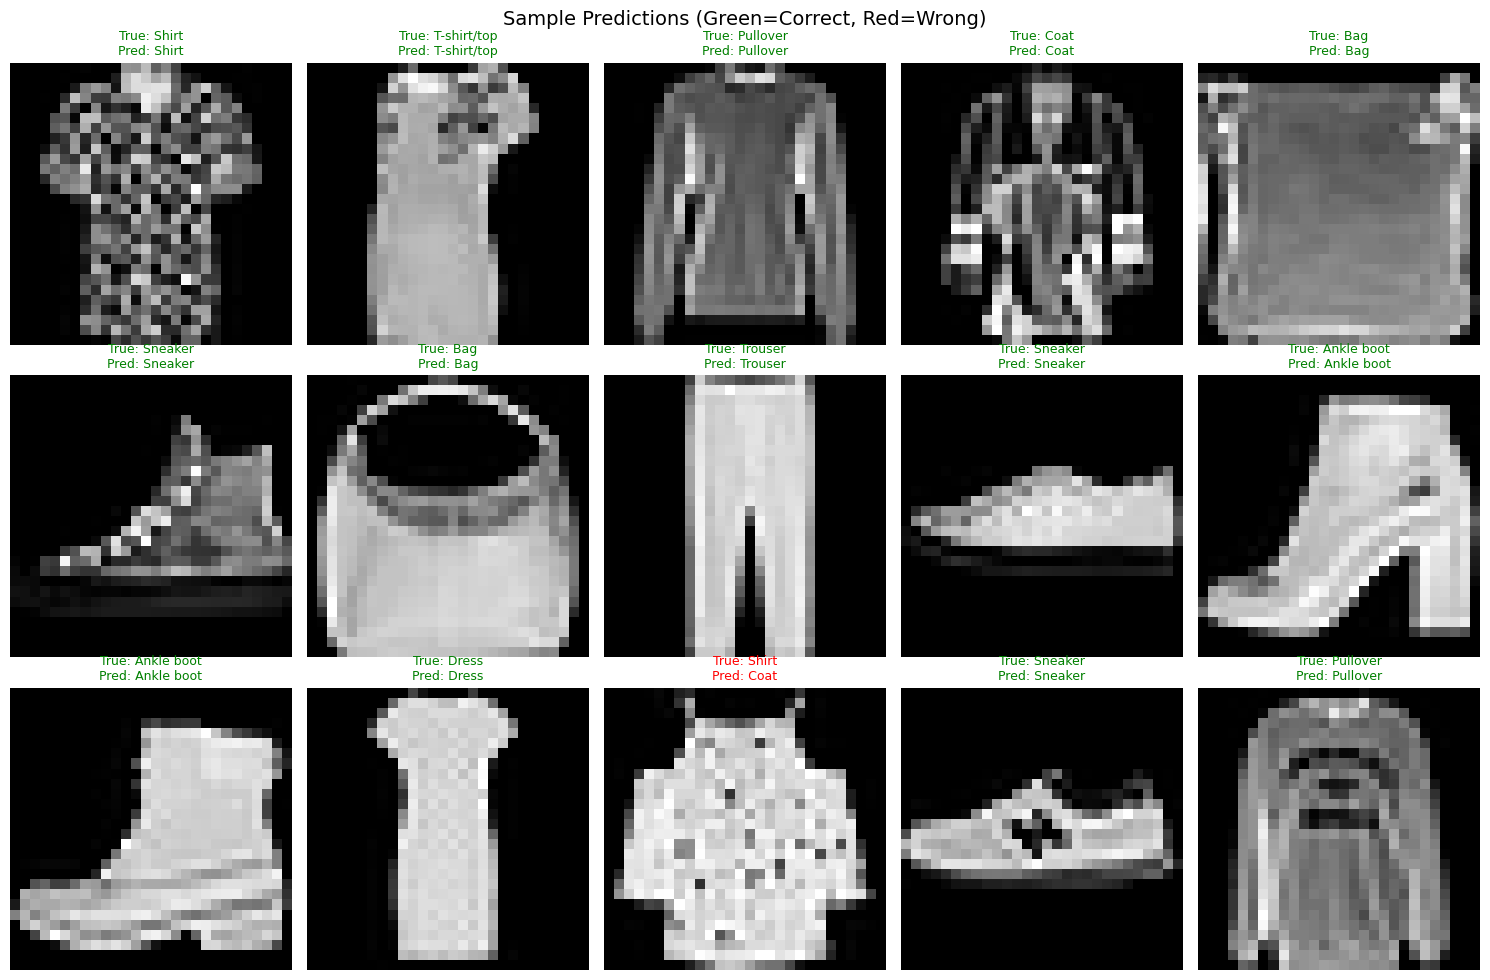

In [10]:
plt.figure(figsize=(15, 10))
indices = np.random.choice(len(X_test), 15, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    true_name = class_names[y_test[idx]]
    pred_name = class_names[y_pred[idx]]
    color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

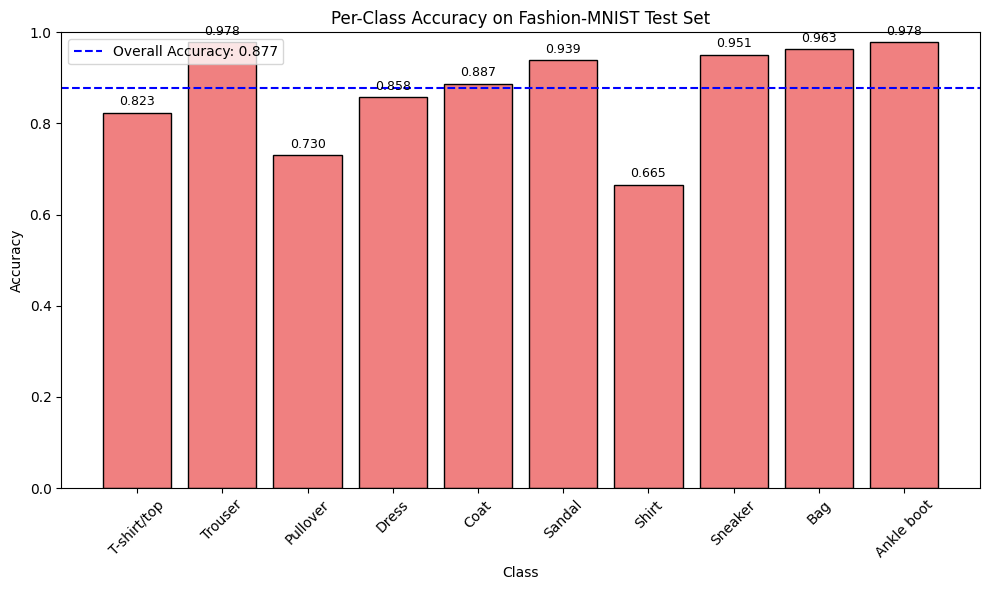

In [11]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, per_class_accuracy, color='lightcoral', edgecolor='black')
plt.axhline(y=test_accuracy, color='b', linestyle='--', label=f'Overall Accuracy: {test_accuracy:.3f}')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy on Fashion-MNIST Test Set')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()

# Add value labels on bars
for bar, acc in zip(bars, per_class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# Reshape images for CNN
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

cnn_model = Sequential([

    Input(shape=(28,28,1)),

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')

])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
cnn_history = cnn_model.fit(

    X_train_cnn,
    y_train,

    epochs=10,
    batch_size=64,
    validation_split=0.2

)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.8095 - loss: 0.5228 - val_accuracy: 0.8475 - val_loss: 0.4190
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.8750 - loss: 0.3418 - val_accuracy: 0.8803 - val_loss: 0.3255
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.8922 - loss: 0.2961 - val_accuracy: 0.8905 - val_loss: 0.3012
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9043 - loss: 0.2624 - val_accuracy: 0.8966 - val_loss: 0.2865
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9114 - loss: 0.2395 - val_accuracy: 0.8988 - val_loss: 0.2828
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9194 - loss: 0.2169 - val_accuracy: 0.9062 - val_loss: 0.2597
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.9278 - loss: 0.1948 - val_accuracy: 0.9089 - val_loss: 0.2483
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 54s 72ms/step - accuracy: 0.9341 - loss: 0.1768 - 

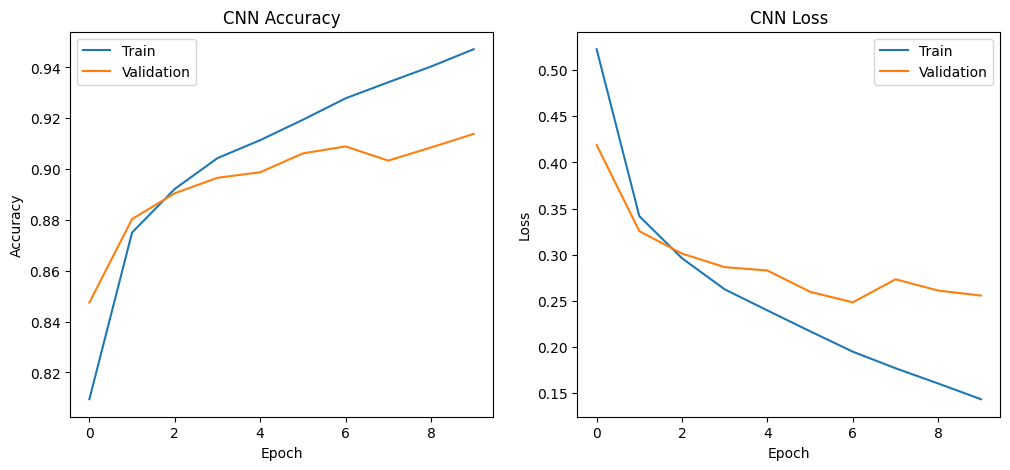

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)

plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [16]:
cnn_pred_probs = cnn_model.predict(X_test_cnn)

cnn_pred = np.argmax(cnn_pred_probs, axis=1)

cnn_accuracy = accuracy_score(y_test, cnn_pred)

print("CNN Test Accuracy =", cnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
CNN Test Accuracy = 0.9075


In [17]:
print(classification_report(
    y_test,
    cnn_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.89      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.89      0.83      0.86      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.86      0.85      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.74      0.73      1000
     Sneaker       0.93      0.98      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



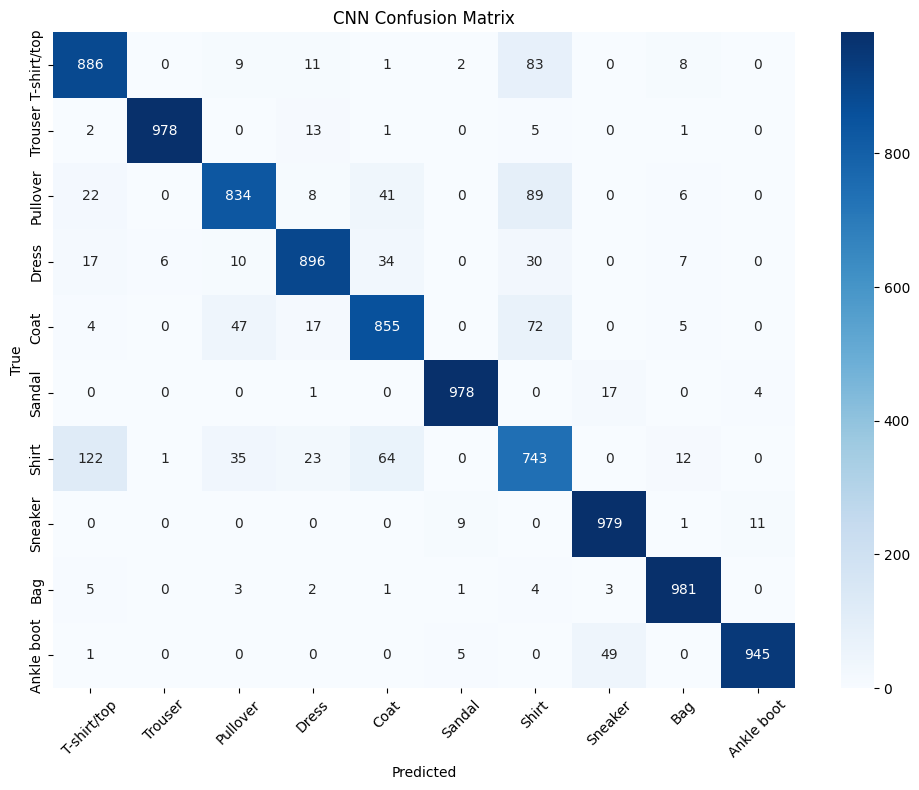

In [18]:
cnn_cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

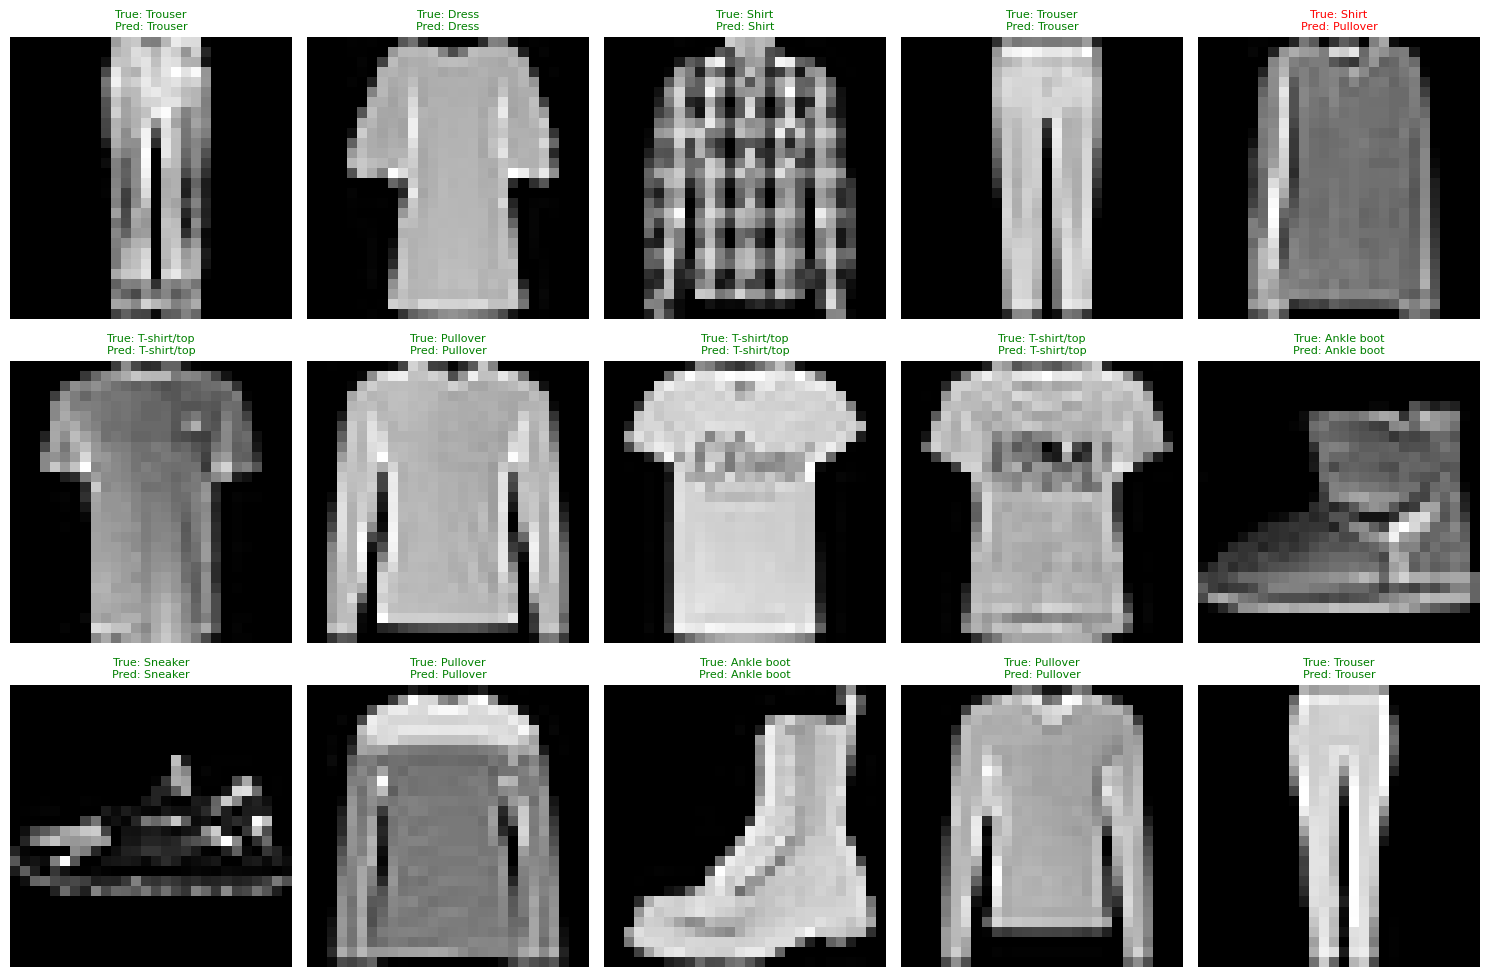

In [19]:
plt.figure(figsize=(15,10))

indices = np.random.choice(len(X_test),15,replace=False)

for i, idx in enumerate(indices):

    plt.subplot(3,5,i+1)

    plt.imshow(X_test[idx], cmap='gray')

    true_name = class_names[y_test[idx]]
    pred_name = class_names[cnn_pred[idx]]

    color = "green" if true_name == pred_name else "red"

    plt.title(
        f"True: {true_name}\nPred: {pred_name}",
        fontsize=8,
        color=color
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [21]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.4MB/s]


In [22]:
class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,32,3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*5*5,128),
            nn.ReLU(),

            nn.Linear(128,10)

        )

    def forward(self,x):

        x = self.conv(x)

        x = self.fc(x)

        return x


torch_model = CNN().to(device)

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    torch_model.parameters(),
    lr=0.001
)

In [24]:
epochs = 10

train_losses = []

for epoch in range(epochs):

    torch_model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = torch_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}  Loss = {epoch_loss:.4f}")

Epoch 1/10  Loss = 0.5307
Epoch 2/10  Loss = 0.3441
Epoch 3/10  Loss = 0.2974
Epoch 4/10  Loss = 0.2636
Epoch 5/10  Loss = 0.2394
Epoch 6/10  Loss = 0.2163
Epoch 7/10  Loss = 0.1952
Epoch 8/10  Loss = 0.1796
Epoch 9/10  Loss = 0.1631
Epoch 10/10  Loss = 0.1488


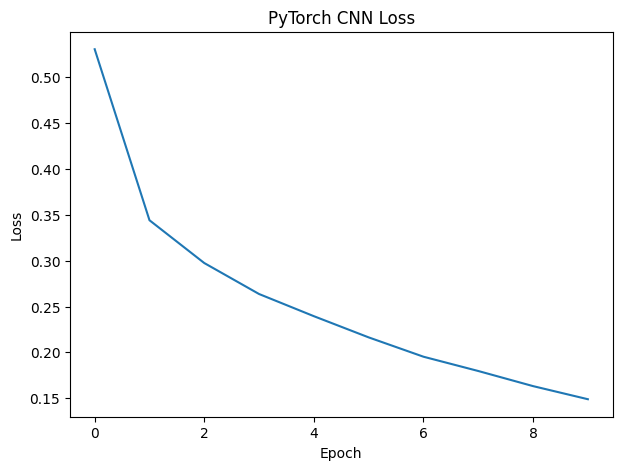

In [25]:
plt.figure(figsize=(7,5))

plt.plot(train_losses)

plt.title("PyTorch CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [26]:
torch_model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = torch_model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

torch_accuracy = correct / total

print("PyTorch CNN Accuracy =", torch_accuracy)

PyTorch CNN Accuracy = 0.9141


In [27]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.86      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.79      0.92      0.85      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.87      0.86      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.80      0.69      0.74      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



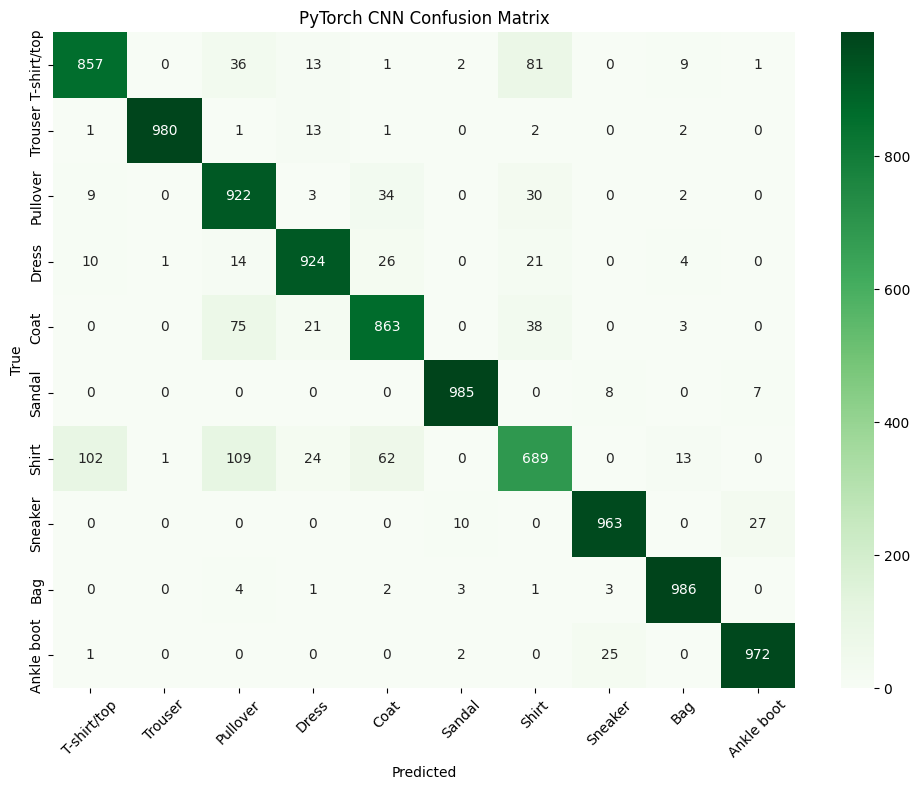

In [28]:
torch_cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    torch_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("PyTorch CNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [29]:
print("=" * 45)
print("Model Comparison")
print("=" * 45)

print(f"Dense Neural Network      : {test_accuracy:.4f}")

print(f"CNN TensorFlow           : {cnn_accuracy:.4f}")

print(f"CNN PyTorch             : {torch_accuracy:.4f}")

Model Comparison
Dense Neural Network      : 0.8772
CNN TensorFlow           : 0.9075
CNN PyTorch             : 0.9141
